# Elliptic Bitcoin Transactions: GraphSAGE Tuning

Notebook 3 of 7. It searches GraphSAGE settings with Optuna on the five temporal folds fixed in notebook 2. The model is trained with focal loss and graph-aware sampling (class-balanced seed nodes and a capped, randomly sampled neighbourhood per layer), and every trial is scored by pooled out-of-fold PR-AUC, which does not depend on a decision threshold.

Tuning is a separate notebook from training so that a bug in training never throws away the study.

## Setup

Installs PyTorch Geometric (pinned), then defines the model, the sampling, the focal loss and the training loop. Training runs in float64: Kaggle assigns Intel and AMD machines at random, their float32 kernels round differently, and 80 epochs amplify that into visibly different scores, while float64 keeps every printed number identical across machines. The focal loss computes its modulating factor in log space, `exp(gamma * logsigmoid(.))`, so its gradient stays finite when a prediction saturates. The model is an input projection, two or three mean-aggregation `SAGEConv` layers, and a linear head on the concatenation of every layer's output (jumping knowledge), which keeps each transaction's own features visible next to its neighbourhood summary. `SMOKE` keeps the full graph but runs 2 trials of 10 epochs, so the timing projection is real; it is off in this version.

In [1]:
import json
import subprocess
import sys
import time
from pathlib import Path

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--progress-bar", "off", "torch_geometric==2.8.0.post1"], check=True, capture_output=True)

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn.functional as F
import torch_geometric
from cycler import cycler
from sklearn.metrics import average_precision_score
from torch_geometric.nn import SAGEConv
from torch_geometric.utils import remove_self_loops, to_undirected

SMOKE = False
SEED = 42
THREADS = 4
TRAIN_LAST = 34
FULL_TRIALS = 30
FULL_EPOCHS = 80
EVERY = 5
TRIALS, MAX_EPOCHS = (2, 10) if SMOKE else (FULL_TRIALS, FULL_EPOCHS)
CHECKPOINTS = tuple(range(EVERY, MAX_EPOCHS + 1, EVERY))
INPUT = Path("/kaggle/input")
OUT = Path("/kaggle/working")
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "text.color": INK, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2, "legend.frameon": False,
    "font.family": "sans-serif", "axes.prop_cycle": cycler(color=SERIES), "axes.titlesize": 11,
})
torch.set_num_threads(THREADS)
torch.use_deterministic_algorithms(True, warn_only=True)
torch.set_default_dtype(torch.float64)
optuna.logging.set_verbosity(optuna.logging.WARNING)
START = time.time()

STRUCTURAL = ["in_degree", "out_degree", "pagerank", "core_number", "clustering", "avg_neighbor_degree", "two_hop_size"]
LOG1P = ("in_degree", "out_degree", "core_number", "avg_neighbor_degree", "two_hop_size")
LOG = ("pagerank",)


def gnn_matrix(raw, structural):
    values = np.array(structural, dtype=float)
    for name in LOG1P:
        i = STRUCTURAL.index(name)
        values[:, i] = np.log1p(values[:, i])
    for name in LOG:
        i = STRUCTURAL.index(name)
        values[:, i] = np.log(values[:, i])
    return np.hstack([np.asarray(raw, dtype=float), values])


class SAGE(torch.nn.Module):
    def __init__(self, d_in, hidden, layers, dropout):
        super().__init__()
        self.inp = torch.nn.Linear(d_in, hidden)
        self.convs = torch.nn.ModuleList([SAGEConv(hidden, hidden, aggr="mean") for _ in range(layers)])
        self.head = torch.nn.Linear(hidden * (layers + 1), 1)
        self.dropout = dropout

    def forward(self, x, edge_indices):
        h = F.dropout(F.relu(self.inp(x)), self.dropout, self.training)
        hidden = [h]
        for conv, edge_index in zip(self.convs, edge_indices):
            h = F.dropout(F.relu(conv(h, edge_index)), self.dropout, self.training)
            hidden.append(h)
        return self.head(torch.cat(hidden, dim=1)).squeeze(-1)


def sample_edges(edge_index, num_nodes, k, gen):
    dst = edge_index[1]
    key = dst.to(torch.float64) + torch.rand(dst.numel(), generator=gen, dtype=torch.float64)
    order = torch.argsort(key, stable=True)
    sorted_dst = dst[order]
    counts = torch.bincount(dst, minlength=num_nodes)
    starts = torch.cumsum(counts, 0) - counts
    rank = torch.arange(dst.numel()) - starts[sorted_dst]
    return edge_index[:, order[rank < k]]


def epoch_seeds(positives, negatives, ratio, gen):
    if ratio is None:
        return torch.cat([positives, negatives])
    take = min(len(negatives), int(ratio) * len(positives))
    pick = negatives[torch.randperm(len(negatives), generator=gen)[:take]]
    return torch.cat([positives, pick])


def focal_loss(logits, target, alpha, gamma):
    ce = F.binary_cross_entropy_with_logits(logits, target, reduction="none")
    modulating = torch.exp(gamma * F.logsigmoid(logits * (1 - 2 * target)))
    a_t = alpha * target + (1 - alpha) * (1 - target)
    return (a_t * modulating * ce).mean()


def predict(model, x, edge):
    model.eval()
    with torch.no_grad():
        return model(x, [edge] * len(model.convs)).numpy().astype(np.float64)


def fit(params, fold, seed, epochs, checkpoints=(), balance=True, loss="focal"):
    torch.manual_seed(seed)
    gen = torch.Generator().manual_seed(seed)
    model = SAGE(X.shape[1], params["hidden"], params["layers"], params["dropout"])
    opt = torch.optim.Adam(model.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    in_fit = (FOLD != fold) & LABELLED
    positives = torch.tensor(np.flatnonzero(in_fit & (TRUE == 1)))
    negatives = torch.tensor(np.flatnonzero(in_fit & (TRUE == 0)))
    held = np.flatnonzero(FOLD == fold)
    history = {}
    for epoch in range(1, epochs + 1):
        model.train()
        seeds = epoch_seeds(positives, negatives, params["ratio"] if balance else None, gen)
        layer_edges = [sample_edges(EDGE, N, params["fanout"], gen) for _ in range(params["layers"])]
        out = model(X, layer_edges)[seeds]
        if loss == "focal":
            value = focal_loss(out, Y[seeds], params["alpha"], params["gamma"])
        else:
            value = F.binary_cross_entropy_with_logits(out, Y[seeds])
        opt.zero_grad()
        value.backward()
        opt.step()
        if epoch in checkpoints:
            history[epoch] = predict(model, X, EDGE)[held]
    return model, history


def find_file(name):
    hits = sorted(INPUT.rglob(name))
    if not hits:
        raise FileNotFoundError(name)
    return hits[0]


def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=110, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def elapsed():
    return f"elapsed {(time.time() - START) / 60:.1f} minutes"


print(f"smoke={SMOKE}, trials={TRIALS}, max epochs={MAX_EPOCHS}")
print(f"torch {torch.__version__}, torch_geometric {torch_geometric.__version__}, optuna {optuna.__version__}, numpy {np.__version__}")

smoke=False, trials=30, max epochs=80
torch 2.11.0+cpu, torch_geometric 2.8.0.post1, optuna 5.0.0, numpy 2.1.3


**Conclusion.** The study runs at full size: 30 trials of up to 80 epochs, in float64. Kaggle's CPU image ships torch 2.11.0, and PyTorch Geometric 2.8.0.post1 installs on top of it without compiled extensions, which the plain-torch neighbour sampler does not need.

## Build the training graph

Aim: assemble the GraphSAGE inputs for every node of steps 1 to 34, labelled or not: the 165 raw features plus the 7 structural features (counts on a log scale, PageRank as a log), standardised with training-period statistics, and the symmetrised edge list. Unknown nodes stay in the graph as message-passing context but never enter the loss.

In [2]:
feat = pd.read_parquet(find_file("features.parquet"))
split = pd.read_parquet(find_file("split.parquet"))
edges = pd.read_parquet(find_file("edges.parquet"))
meta = json.loads(find_file("feature_meta.json").read_text(encoding="utf-8"))
RAW = meta["raw"]
train = feat[feat.time_step <= TRAIN_LAST].merge(split[["txId", "temporal_fold"]], on="txId").reset_index(drop=True)
x_np = gnn_matrix(train[RAW].to_numpy(np.float64), train[STRUCTURAL].to_numpy(np.float64))
MEAN = x_np.mean(axis=0)
STD = x_np.std(axis=0)
STD[STD == 0] = 1.0
X = torch.tensor((x_np - MEAN) / STD, dtype=torch.float64)
LABEL = train.label.to_numpy()
LABELLED = LABEL >= 0
TRUE = (LABEL == 1).astype(int)
Y = torch.tensor(TRUE, dtype=torch.float64)
FOLD = train.temporal_fold.to_numpy()
N = len(train)
pos = pd.Series(np.arange(N), index=train.txId.to_numpy())
inside = edges.txId1.isin(pos.index) & edges.txId2.isin(pos.index)
edge_index = torch.tensor(np.vstack([pos.loc[edges.txId1[inside]].to_numpy(), pos.loc[edges.txId2[inside]].to_numpy()]), dtype=torch.long)
edge_index, _ = remove_self_loops(edge_index)
EDGE = to_undirected(edge_index, num_nodes=N)
print(f"nodes {N:,}, input features {X.shape[1]}, directed edges {edge_index.shape[1]:,}, symmetrised edges {EDGE.shape[1]:,}")
for k in range(5):
    rows = (FOLD == k) & LABELLED
    print(f"fold {k}: nodes {int((FOLD == k).sum()):,}, labelled {int(rows.sum()):,}, illicit {int(TRUE[rows].sum()):,}")

nodes 136,265, input features 172, directed edges 156,843, symmetrised edges 313,686
fold 0: nodes 24,738, labelled 5,983, illicit 76
fold 1: nodes 26,632, labelled 5,513, illicit 430
fold 2: nodes 35,101, labelled 6,493, illicit 1,005
fold 3: nodes 24,793, labelled 6,211, illicit 826
fold 4: nodes 25,001, labelled 5,694, illicit 1,125


**Conclusion.** The training graph holds all 136,265 transactions of steps 1 to 34, labelled or not, with 172 inputs per node (165 raw, 7 structural) and 313,686 symmetrised edges. The folds match notebook 2. Fold 0 has only 76 illicit transactions, so its per-fold PR-AUC is the noisiest; this is why the trial value pools all out-of-fold predictions.

## Timing check

Aim: measure seconds per epoch at the most expensive settings in the search space and project the full study's runtime before committing to it. If the projection exceeds six hours, the search space is narrowed before the full run.

In [3]:
probe = {"layers": 3, "hidden": 64, "dropout": 0.2, "lr": 5e-3, "weight_decay": 1e-5, "alpha": 0.75, "gamma": 2.0, "ratio": 8, "fanout": 25}
t0 = time.time()
fit(probe, 0, SEED, 3)
per_epoch = (time.time() - t0) / 3
print(f"seconds per epoch at the largest settings: {per_epoch:.2f}")
print(f"projected full study minutes without pruning: {per_epoch * FULL_EPOCHS * 1.2 * 5 * FULL_TRIALS / 60:.0f}")

seconds per epoch at the largest settings: 3.61
projected full study minutes without pruning: 867


**Conclusion.** At the most expensive settings left in the search space (3 layers, hidden 64) one float64 epoch takes about 3.5 seconds (3.48 and 3.61 on the two runs' machines), so the study's worst case is about 835 to 867 minutes if every trial used those settings and none were pruned. In practice the cost depends on which settings the sampler favours; the two full runs took 7.2 and 7.5 hours, well inside Kaggle's 12-hour limit.

## The Optuna study

Aim: search 30 trials of GraphSAGE settings (hidden size 32 or 64 and up to 80 epochs, narrowed after the smoke run's timing check) with a seeded TPE sampler. For each trial, five fold models are trained (seed 42) and every held-out fold is scored every 5 epochs; the trial's value is the pooled out-of-fold PR-AUC at the best common epoch count, which becomes the tuned training length. A median pruner stops trials whose running mean fold PR-AUC trails the others, and a trial whose training diverges to non-finite scores is recorded with PR-AUC 0 rather than stopping the study.

In [4]:
def suggest(trial):
    return {
        "layers": trial.suggest_categorical("layers", [2, 3]),
        "hidden": trial.suggest_categorical("hidden", [32, 64]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "lr": trial.suggest_float("lr", 1e-3, 2e-2, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        "alpha": trial.suggest_float("alpha", 0.25, 0.95),
        "gamma": trial.suggest_float("gamma", 0.0, 3.0),
        "ratio": trial.suggest_categorical("ratio", [1, 2, 4, 8]),
        "fanout": trial.suggest_categorical("fanout", [5, 10, 15, 25]),
    }


def objective(trial):
    params = suggest(trial)
    t0 = time.time()
    preds = {e: np.zeros(N) for e in CHECKPOINTS}
    fold_best = []
    for fold in range(5):
        _, history = fit(params, fold, SEED, MAX_EPOCHS, CHECKPOINTS)
        held = np.flatnonzero(FOLD == fold)
        lab = LABELLED[held]
        if not all(np.isfinite(p).all() for p in history.values()):
            print(f"trial {trial.number} diverged in fold {fold}, recorded as pr_auc 0")
            print(f"trial {trial.number} elapsed {(time.time() - t0) / 60:.1f} minutes")
            trial.set_user_attr("epochs", 0)
            trial.set_user_attr("curve", [0.0] * len(CHECKPOINTS))
            return 0.0
        for e, p in history.items():
            preds[e][held] = p
        fold_best.append(max(average_precision_score(TRUE[held][lab], history[e][lab]) for e in CHECKPOINTS))
        trial.report(float(np.mean(fold_best)), fold)
        if trial.should_prune():
            print(f"trial {trial.number} pruned after fold {fold}, running fold pr_auc {np.mean(fold_best):.4f}")
            print(f"trial {trial.number} elapsed {(time.time() - t0) / 60:.1f} minutes")
            raise optuna.TrialPruned()
    curve = {e: average_precision_score(TRUE[LABELLED], preds[e][LABELLED]) for e in CHECKPOINTS}
    best_epoch = max(curve, key=curve.get)
    trial.set_user_attr("epochs", int(best_epoch))
    trial.set_user_attr("curve", [float(curve[e]) for e in CHECKPOINTS])
    print(f"trial {trial.number}: pr_auc {curve[best_epoch]:.4f} at epoch {best_epoch} | {params}")
    print(f"trial {trial.number} elapsed {(time.time() - t0) / 60:.1f} minutes, total {elapsed()}")
    return curve[best_epoch]


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1),
)
study.optimize(objective, n_trials=TRIALS)
print(elapsed())

trial 0: pr_auc 0.9084 at epoch 80 | {'layers': 3, 'hidden': 32, 'dropout': 0.07800932022121826, 'lr': 0.001595708469414836, 'weight_decay': 1.493656855461763e-06, 'alpha': 0.8563233020424545, 'gamma': 1.8033450352296265, 'ratio': 4, 'fanout': 25}
trial 0 elapsed 12.8 minutes, total elapsed 13.0 minutes
trial 1: pr_auc 0.9290 at epoch 80 | {'layers': 2, 'hidden': 64, 'dropout': 0.06974693032602092, 'lr': 0.002399324290681272, 'weight_decay': 1.2562773503807034e-05, 'alpha': 0.5692489889519251, 'gamma': 2.3555278841790406, 'ratio': 4, 'fanout': 25}
trial 1 elapsed 17.9 minutes, total elapsed 30.9 minutes
trial 2: pr_auc 0.9144 at epoch 80 | {'layers': 2, 'hidden': 32, 'dropout': 0.34211651325607845, 'lr': 0.0037381058681917956, 'weight_decay': 2.3233503515390116e-06, 'alpha': 0.5966238370778891, 'gamma': 0.10316556334565519, 'ratio': 1, 'fanout': 25}
trial 2 elapsed 10.0 minutes, total elapsed 41.0 minutes
trial 3: pr_auc 0.7927 at epoch 80 | {'layers': 3, 'hidden': 32, 'dropout': 0.460

**Conclusion.** The study finished in 7.2 to 7.5 hours across the two runs: 23 trials completed and 7 were pruned, six of them after only two of the five folds. The seventh, trial 24, was pruned only after all five folds had run, so pruning it saved no time. No trial diverged. After trial 12 the sampler concentrated on 2 layers, hidden size 64 and a fan-out of 25, and every trial from there scored between 0.927 and 0.939, so the optimum is a broad plateau rather than a sharp peak. Trial 25 is best with a pooled out-of-fold PR-AUC of 0.9394, with trial 26 a hair behind at 0.9392. These scores come from the training period only; the test period drifts (notebook 1), so test scores will be lower.

## Best settings

Aim: record the winning settings and tuned epoch count for notebook 4, and compare the top trials to see how sharply the objective peaks.

completed trials 23, pruned 7
 trial  pr_auc  epochs  layers  hidden  dropout     lr  weight_decay  alpha  gamma  ratio  fanout
    25  0.9394      75       2      64   0.0624 0.0069        0.0000 0.6539 1.6453      4      25
    26  0.9392      80       2      64   0.0531 0.0073        0.0000 0.7679 1.4272      4      25
    22  0.9380      80       2      64   0.1424 0.0063        0.0000 0.6423 2.1146      4      25
    28  0.9375      80       2      64   0.1071 0.0047        0.0000 0.6220 2.0069      1      25
    29  0.9364      80       2      64   0.0589 0.0048        0.0001 0.7035 1.6135      4      25
    18  0.9361      70       2      64   0.1222 0.0110        0.0000 0.6765 1.8117      4      25
    13  0.9353      70       2      64   0.1527 0.0117        0.0000 0.5744 1.8175      4      25
    27  0.9338      70       2      64   0.0123 0.0073        0.0001 0.6665 0.9296      4      25
    16  0.9338      80       2      64   0.1751 0.0075        0.0000 0.5319 1.6828      

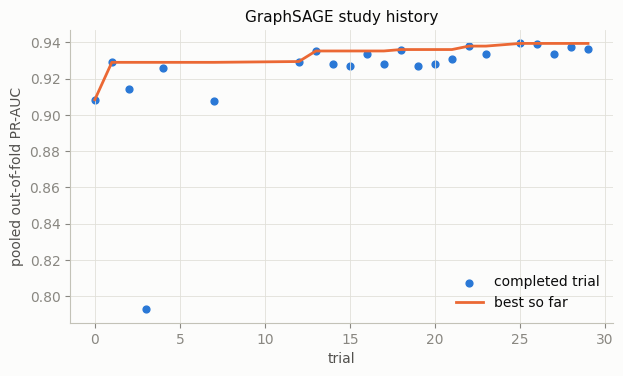

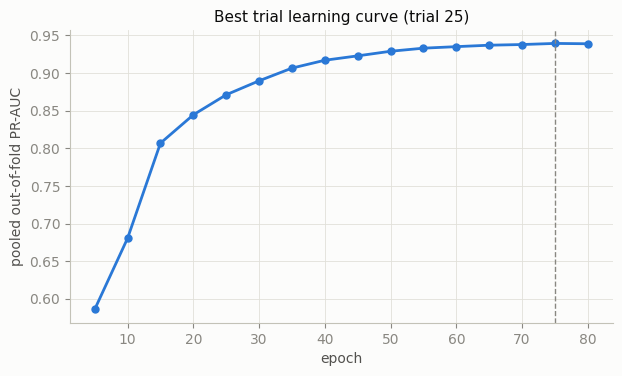

In [5]:
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
print(f"completed trials {len(completed)}, pruned {len(pruned)}")
table = pd.DataFrame([{"trial": t.number, "pr_auc": t.value, "epochs": t.user_attrs["epochs"], **t.params} for t in completed]).sort_values("pr_auc", ascending=False)
print(table.head(10).round(4).to_string(index=False))
best = study.best_trial
best_params = {**best.params, "epochs": int(best.user_attrs["epochs"]), "pr_auc": float(best.value), "trial": int(best.number)}
(OUT / "best_params.json").write_text(json.dumps(best_params, indent=2), encoding="utf-8")
table.to_csv(OUT / "optuna_gnn.csv", index=False)
print(json.dumps(best_params, indent=2))
fig, ax = plt.subplots(figsize=(7, 3.8))
numbers = [t.number for t in completed]
values = [t.value for t in completed]
ax.scatter(numbers, values, color=SERIES[0], s=24, label="completed trial")
ax.plot(numbers, np.maximum.accumulate(values), color=SERIES[1], label="best so far")
ax.set(xlabel="trial", ylabel="pooled out-of-fold PR-AUC", title="GraphSAGE study history")
ax.legend()
save(fig, "study_history")
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(CHECKPOINTS, best.user_attrs["curve"], color=SERIES[0], marker="o", markersize=5)
ax.axvline(best_params["epochs"], color=MUTED, linestyle="--", linewidth=1)
ax.set(xlabel="epoch", ylabel="pooled out-of-fold PR-AUC", title=f"Best trial learning curve (trial {best.number})")
save(fig, "best_trial_curve")

**Conclusion.** The winning settings are 2 layers, hidden size 64, dropout 0.062, learning rate 0.0069, weight decay 3.2e-5, focal alpha 0.654 and gamma 1.645, class-balanced seeds at a 1:4 illicit-to-licit ratio, and up to 25 sampled neighbours per layer, trained for 75 epochs. A gamma well above 1 means the focal term is active rather than reduced to weighted cross-entropy; notebook 4's ablation measures whether it actually helps. The learning curve climbs to 0.93 by epoch 50 and then flattens, peaking at epoch 75, so the 80-epoch cap does not bind for this trial.